In [50]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy

## Generate random centroids
1. Here k random datapoints from the dataset is returned as k centroids of k cluster

In [51]:
def centroids_init(X:numpy.ndarray, k:int):
    '''
    Returns k random data points from X 

    Args:
        X ndarray(m, n): Dataset with m rows and n column
        k int: No of centroid to make
            print(m_dis)

    Returns:
        centroids ndarray(k, n): Return k random datapoints that are consider centroid of k clusters
    '''
    m,n = X.shape
    ids = np.random.randint(0, m, size=k)
    return X[ids, :]

# test
X_temp = np.random.randn(10, 3)
print(f"X: \n{X_temp}")

centroids_temp = centroids_init(X_temp, 3)
print(f"Centorids: \n{centroids_temp}")

X: 
[[ 0.79551101 -1.42513636  0.32189072]
 [ 0.40993519 -1.3869563  -1.09376282]
 [ 0.12603451  0.12763661  1.96581278]
 [-1.51435605 -0.93513523 -0.69716453]
 [ 0.23051895 -1.23279511  0.60393157]
 [-0.72381609 -0.6979213  -1.22478152]
 [-1.54084399 -0.85599775 -0.32968049]
 [ 0.28215926  0.76031738 -0.18354983]
 [ 0.07422427 -0.229429   -0.48628342]
 [-0.58997473  0.19351445 -0.63257007]]
Centorids: 
[[-1.54084399 -0.85599775 -0.32968049]
 [ 0.28215926  0.76031738 -0.18354983]
 [ 0.28215926  0.76031738 -0.18354983]]


## Closest centroid 
- Closest centroid index for corresponding datapoint

In [52]:
def closest_centroid(X: numpy.ndarray, centroids: numpy.ndarray):
    '''
    For each datapoint, return array of index of closest centroid for corresponding data point.

    Args:
        X ndarray(m,n): dataset with m rows and n columns
        centroids ndarray(k, n) 
    Returns:
        ids ndarray(m): centroid index closes to corresponding data point 
    '''
    k = centroids.shape[0]
    m, n = X.shape

    m_dis = np.ones(m) * float('inf')
    ids = np.zeros(m)

    for i, centroid in enumerate(centroids):
        curr_dis =  np.sum((X-centroid)**2, axis=1)
        gt = m_dis > curr_dis
        m_dis[gt] = curr_dis[gt]
        ids[gt] = i
            
    return ids

# test
X_temp = np.random.randint(0, 20, size=(10, 2))
centroids = X_temp[(np.random.randint(0, 10, 3))]

print(f"X: \n{X_temp}\n")
print(f"Centroids: \n{centroids}\n")

ids_temp = closest_centroid(X_temp, centroids)
print(f"cluster indices for each datapoint: {ids_temp}")

X: 
[[ 2 19]
 [ 5  7]
 [10 19]
 [14 10]
 [ 9  2]
 [ 0  7]
 [ 8  0]
 [ 9 15]
 [15  0]
 [15 10]]

Centroids: 
[[15 10]
 [10 19]
 [ 0  7]]

cluster indices for each datapoint: [1. 2. 1. 0. 0. 2. 2. 1. 0. 0.]


## Cost fucntion (Distortion function)

$$ J(X) = \sum_{i=0}^m |X_i - C[ID_i]| ^ 2 $$

Here: 
- $X_i$ is the ith data point in dataset
- $C$ is the centroid datapoints
- $ID_i$ is index of closes centroid to ith data point 

In [53]:
def compute_distortion(X: numpy.ndarray, C: numpy.ndarray, ids: numpy.array):
    '''
    Compute distortion fucntion

    Args:
        X ndarray(m, n): datapoints with m row and n columns
        C ndarray(k, n): centroid data points
        ids ndarray(m): id of closes centroid in C to correspoinding data point in X
    '''
    m = X.shape[0]

    total_dist = 0
    for i, centroid in enumerate(C):
        ids_i = ids == i
        cluster_i = X[ids_i, :]
        dist = np.sum((cluster_i-centroid) ** 2, axis=1)
        total_dist += np.sum(dist)
    
    cost = total_dist / m
    return cost

# test
X_temp = np.random.randint(0, 10, (10, 2))
centroids = X_temp[(np.random.randint(0, 10, 3))]
ids = np.random.randint(0, 3, 10)

print(f"X_temp: \n{X_temp}")
print(f"Centroids: \n{centroids}")
print(f"ids: \n{ids}")

cost_temp = compute_distortion(X_temp, centroids, ids) 
cost_temp

X_temp: 
[[4 7]
 [4 6]
 [5 1]
 [0 4]
 [9 5]
 [1 2]
 [1 5]
 [3 3]
 [5 0]
 [8 0]]
Centroids: 
[[4 6]
 [4 7]
 [5 1]]
ids: 
[1 0 0 1 0 2 2 0 0 2]


np.float64(18.3)

## Calculate Centroid

In [54]:
def compute_centroids(X:numpy.ndarray, C:numpy.ndarray, ids:numpy.array):
    '''
    For each cluster, its datapoints coordinate values are averaged and assign to its centroid coordnate values

    Args:
        X ndarray(m, n): datapoints with m row and n columns
        C ndarray(k, n): centroid data points
        ids ndarray(m): id of closes centroid in C to correspoinding data point in X
    Return:
        avg_centroids(k, n): new centroids of the clusters
    '''
    avg_centroids = np.zeros_like(C, dtype=np.float64)

    for i,centroid in enumerate(C):
        ids_i = ids == i
        cluster_i = X[ids_i, :]
        avg_C = np.average(cluster_i, axis=0)
        avg_centroids[i] = avg_C
    
    return avg_centroids

# test
X_temp = np.random.randint(0, 10, (10, 2))
centroids_temp = X_temp[(np.random.randint(0, 10, 2))]
ids_temp = np.random.randint(0, 2, 10)

print(f"X: \n{X_temp}\n")
print(f"centroids: \n{centroids_temp}\n")
print(f"ids: \n{ids_temp}\n")

ids_0 = ids_temp == 0
print(f"actual avg_centroid 1: {np.average(X_temp[ids_0, :], axis=0)}")
ids_1 = ids_temp == 1
print(f"actual avg_centroid 2: {np.average(X_temp[ids_1, :], axis=0)}\n")

print(f"calculated avg_centroids: \n{compute_centroids(X_temp, centroids_temp, ids_temp)}")

X: 
[[7 2]
 [0 3]
 [0 9]
 [6 3]
 [4 0]
 [4 6]
 [1 9]
 [9 5]
 [4 8]
 [0 3]]

centroids: 
[[9 5]
 [4 0]]

ids: 
[1 0 1 0 0 0 0 0 0 1]

actual avg_centroid 1: [4.         4.85714286]
actual avg_centroid 2: [2.33333333 4.66666667]

calculated avg_centroids: 
[[4.         4.85714286]
 [2.33333333 4.66666667]]


In [55]:
def run_kmeans(X: numpy.ndarray, k:int, *, iter:int=10):
    m, n = X.shape
    centroids = centroids_init(X, k)
    ids = closest_centroid(X, centroids)
    cost = compute_distortion(X, centroids, ids)
    history = [[np.copy(centroids),cost]]

    for i in range(iter):
        centroids = compute_centroids(X, centroids, ids)
        ids = closest_centroid(X, centroids)
        cost = compute_distortion(X, centroids, ids)
        history.append([np.copy(centroids),cost])


    return centroids, ids, history

## Current implementation Testing
- Took first two features of the wine data in consideration

In [56]:
from sklearn.datasets import load_wine
data = load_wine()

In [57]:
X = data['data'][:, :2]
y = data['target']

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")

X.shape: (178, 2)
y.shape: (178,)


In [58]:
centroids, ids, history = run_kmeans(X[:, :2], 3, iter=10)
costs = [cost for [_, cost] in history]
centroids_history = np.array([centroids for [centroids, _] in history])


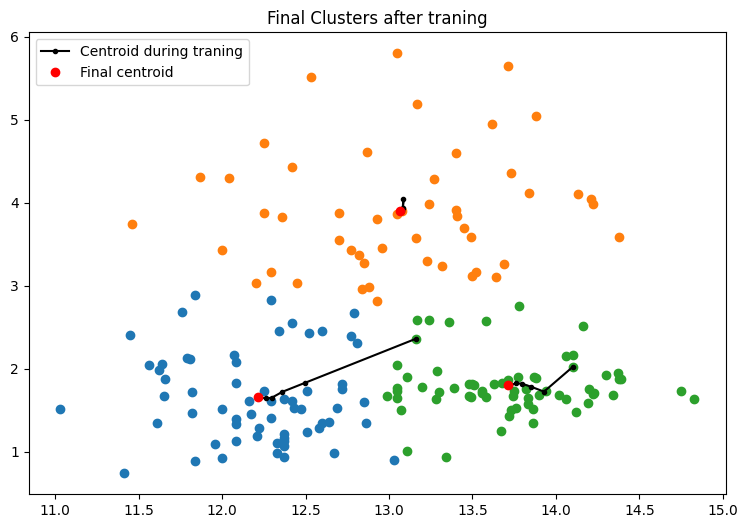

In [59]:
plt.figure(figsize=(9, 6))
for i in range(3):
    A = X[(ids==i), :2]
    plt.scatter(A[:, 0], A[:, 1])
    if i == 0:
        plt.plot(centroids_history[:, i, 0],centroids_history[:, i, 1], 'ko-', markersize=3, label='Centroid during traning')
        plt.plot(centroids[i, 0], centroids[i, 1], 'ro', label='Final centroid')
    else:
        plt.plot(centroids_history[:, i, 0],centroids_history[:, i, 1], 'ko-', markersize=3)
        plt.plot(centroids[i, 0], centroids[i, 1], 'ro')




plt.title('Final Clusters after traning')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Distortion function cost: Kmeans')

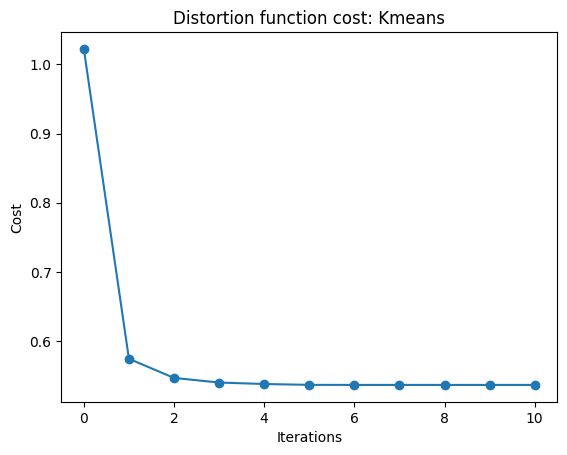

In [60]:

plt.plot(costs, 'o', ls='-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Distortion function cost: Kmeans")

## class Kmeans testing
- Testing the kmeans.py package made from starch

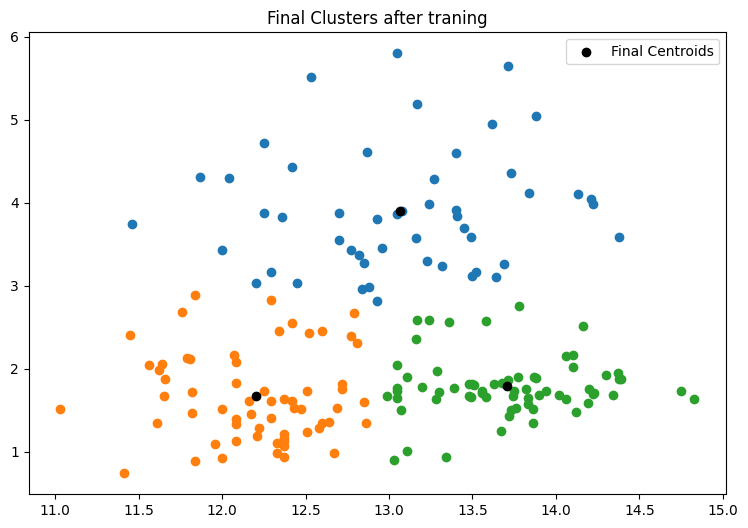

In [61]:
from kmeans import Kmeans

model = Kmeans(3)
model.fit(X)
labels = model.predict(X)
centroids = model.centroids

plt.figure(figsize=(9, 6))
for i in range(3):
    A = X[(labels==i), :]
    plt.scatter(A[:, 0], A[:, 1])
    if i == 0:
        plt.scatter(centroids[i, 0], centroids[i, 1], c='k', label='Final Centroids')
    else:
        plt.scatter(centroids[i, 0], centroids[i, 1], c='k')




plt.title('Final Clusters after traning')
plt.legend()
plt.show()